In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# load our processed data
crashes   = pd.read_csv("../data/processed/crashes_cleaned.csv")
seg_risk  = pd.read_csv("../data/processed/segment_risk.csv")
roads     = gpd.read_file("../data/external/nyc_roads.gpkg")

print(f"Crashes: {len(crashes):,}")
print(f"Segments with risk: {len(seg_risk):,}")
print(f"Roads: {len(roads):,}")

Crashes: 461,425
Segments with risk: 63,265
Roads: 122,272


In [6]:
import requests
import json

print("Downloading NYC borough boundaries...")

url = "https://data.cityofnewyork.us/resource/7t3b-ywvw.geojson?$limit=10"
r = requests.get(url)
print(f"Status: {r.status_code}")

# use a reliable alternative source
url = "https://raw.githubusercontent.com/dwillis/nyc-maps/master/boroughs.geojson"
boroughs = gpd.read_file(url)
boroughs = boroughs.to_crs("EPSG:4326")
print(f"Boroughs loaded: {len(boroughs)}")
print(boroughs.columns.tolist())

boroughs.to_file("../data/external/nyc_boroughs.gpkg", driver="GPKG")
print("Saved.")

Status: 404
Boroughs loaded: 5
['BoroCode', 'BoroName', 'Shape_Leng', 'Shape_Area', 'geometry']
Saved.


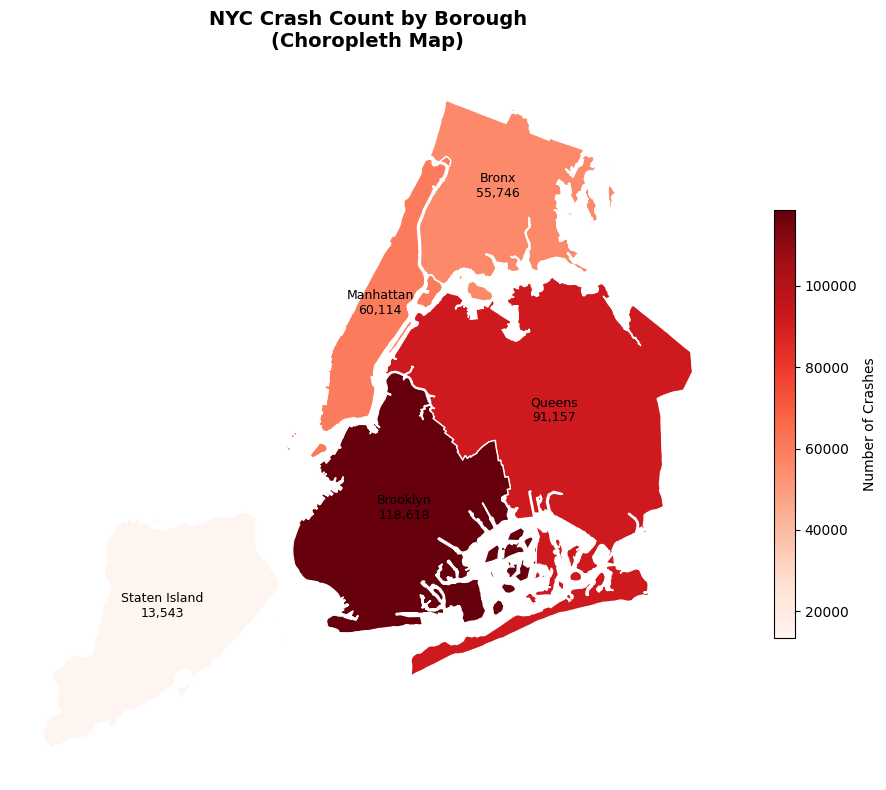

Saved choropleth_borough.png


In [8]:
# count crashes per borough
borough_crashes = crashes['borough'].value_counts().reset_index()
borough_crashes.columns = ['BoroName', 'crash_count']
borough_crashes['BoroName'] = borough_crashes['BoroName'].str.title()

# merge with geometry
borough_map = boroughs.merge(borough_crashes, on='BoroName', how='left')

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
borough_map.plot(
    column='crash_count',
    cmap='Reds',
    linewidth=1,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Number of Crashes', 'shrink': 0.6},
    ax=ax
)
ax.set_title('NYC Crash Count by Borough\n(Choropleth Map)',
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

for _, row in borough_map.iterrows():
    if row.geometry:
        centroid = row.geometry.centroid
        ax.annotate(
            f"{row['BoroName']}\n{row['crash_count']:,.0f}",
            xy=(centroid.x, centroid.y),
            fontsize=9, ha='center', color='black'
        )

plt.tight_layout()
plt.savefig("../outputs/figures/choropleth_borough.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved choropleth_borough.png")

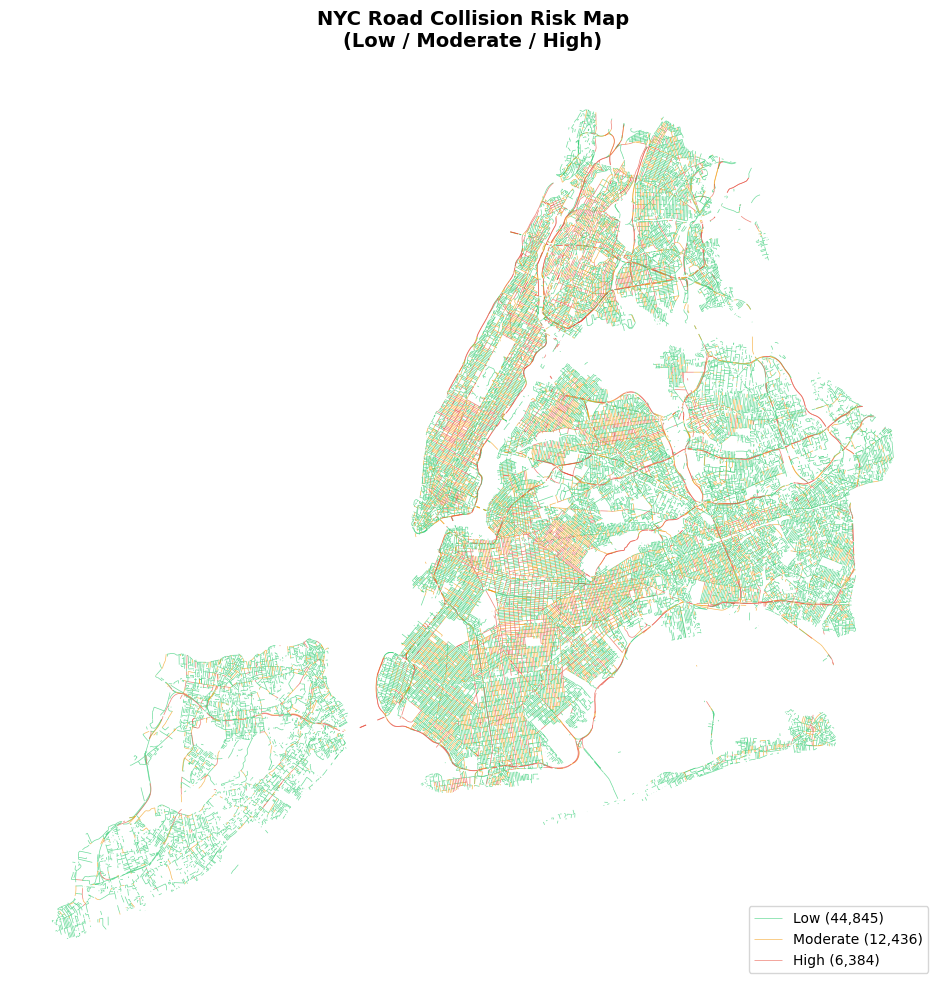

Saved choropleth_risk.png


In [9]:
# merge risk onto road geometries
roads['physicalid']    = roads['physicalid'].astype(str)
seg_risk['physicalid'] = seg_risk['physicalid'].astype(str)
roads_risk = roads.merge(seg_risk[['physicalid','risk_class','total_csi']],
                          on='physicalid', how='inner')
roads_risk = roads_risk.to_crs("EPSG:4326")

# plot risk map
color_map = {'Low':'#2ecc71', 'Moderate':'#f39c12', 'High':'#e74c3c'}

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

for risk_class, color in color_map.items():
    subset = roads_risk[roads_risk['risk_class'] == risk_class]
    subset.plot(ax=ax, color=color, linewidth=0.5,
                label=f'{risk_class} ({len(subset):,})', alpha=0.7)

ax.set_title('NYC Road Collision Risk Map\n(Low / Moderate / High)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10)
ax.axis('off')

plt.tight_layout()
plt.savefig("../outputs/figures/choropleth_risk.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved choropleth_risk.png")

In [10]:
import subprocess
subprocess.run(["pip", "install", "esda", "libpysal", "--break-system-packages", "-q"])
print("Done.")

Done.


In [11]:
# ## Spatial Autocorrelation — Moran's I
# 
# Spatial autocorrelation measures whether similar values cluster together geographically.
# Tobler's First Law: "Everything is related to everything else, but near things 
# are more related than distant things."
#
# We first build a spatial weights matrix — defines which segments are "neighbors"

import libpysal
from esda.moran import Moran, Moran_Local
import warnings
warnings.filterwarnings('ignore')

# work with a sample for performance
sample = roads_risk[roads_risk['risk_class'].notna()].sample(
    n=5000, random_state=42).copy()
sample = sample.to_crs("EPSG:3857")

print("Building spatial weights matrix...")
# Queen contiguity — segments sharing any point are neighbors
w = libpysal.weights.Queen.from_dataframe(sample, silence_warnings=True)
w.transform = 'r'  # row-standardize so each row sums to 1

print(f"Weights matrix built.")
print(f"Average neighbors per segment: {w.mean_neighbors:.1f}")

C:\Users\AA\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Building spatial weights matrix...
Weights matrix built.
Average neighbors per segment: 0.3


GLOBAL MORAN'S I RESULTS
Moran's I statistic: 0.1643
Expected value:      -0.0002
p-value:             0.0010
z-score:             4.7070

Result: POSITIVE spatial autocorrelation
High risk roads CLUSTER together — not randomly distributed.


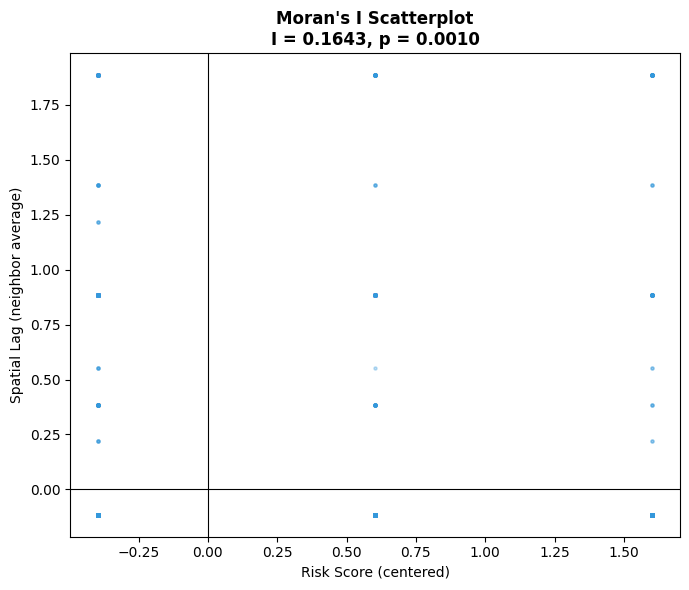

Saved morans_i.png


In [13]:
# Global Moran's I tells us if high risk roads cluster together across all of NYC
# Value ranges from -1 (dispersed) to +1 (clustered), 0 = random

risk_numeric = sample['risk_class'].map({'Low':0,'Moderate':1,'High':2}).values

moran = Moran(risk_numeric, w)

print("=" * 40)
print("GLOBAL MORAN'S I RESULTS")
print("=" * 40)
print(f"Moran's I statistic: {moran.I:.4f}")
print(f"Expected value:      {moran.EI:.4f}")
print(f"p-value:             {moran.p_sim:.4f}")
print(f"z-score:             {moran.z_sim:.4f}")
print()
if moran.p_sim < 0.05:
    if moran.I > moran.EI:
        print("Result: POSITIVE spatial autocorrelation")
        print("High risk roads CLUSTER together — not randomly distributed.")
    else:
        print("Result: NEGATIVE spatial autocorrelation")
        print("High risk roads are DISPERSED across NYC.")
else:
    print("Result: No significant spatial autocorrelation (p > 0.05)")

# correct moran scatterplot
# spatial lag = weighted average of neighbors' risk
spatial_lag = libpysal.weights.lag_spatial(w, risk_numeric)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    risk_numeric - risk_numeric.mean(),
    spatial_lag - spatial_lag.mean(),
    alpha=0.3, s=5, color='#3498db'
)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Risk Score (centered)")
ax.set_ylabel("Spatial Lag (neighbor average)")
ax.set_title(f"Moran's I Scatterplot\nI = {moran.I:.4f}, p = {moran.p_sim:.4f}",
             fontweight='bold')
plt.tight_layout()
plt.savefig("../outputs/figures/morans_i.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved morans_i.png")


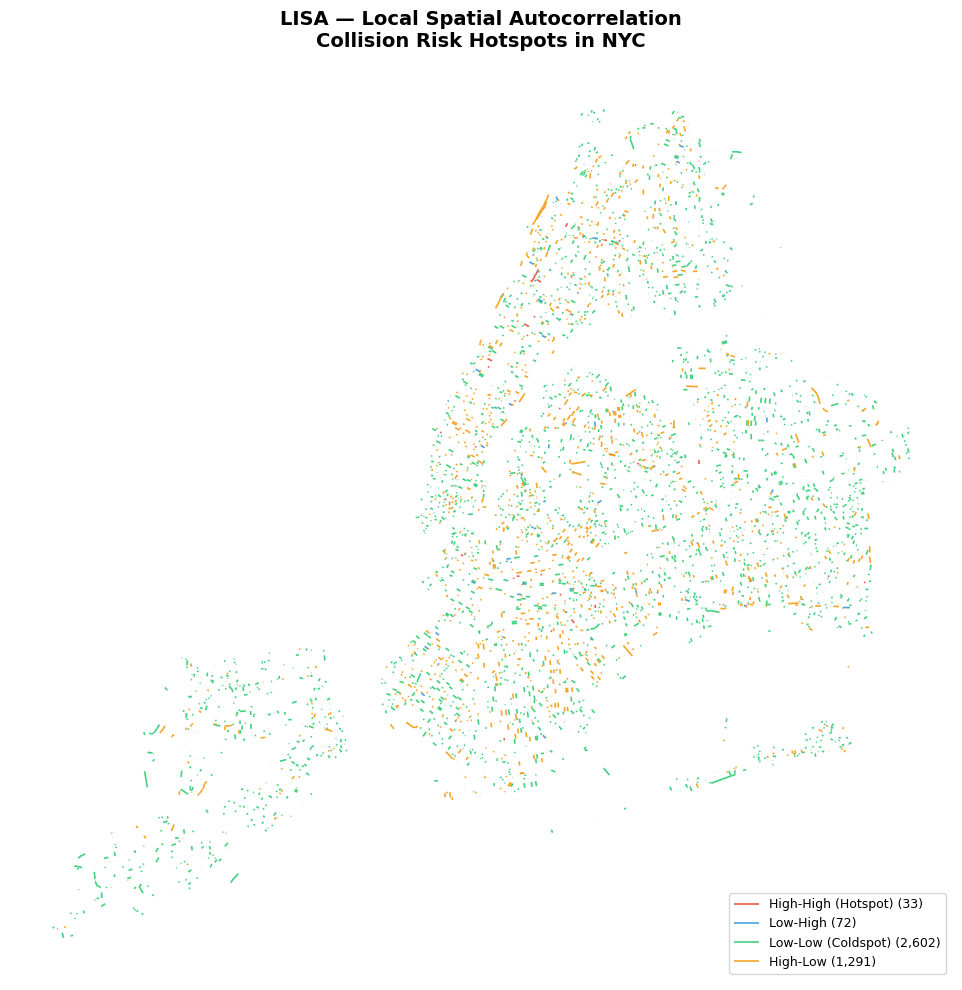

Saved lisa_clusters.png

LISA Cluster Summary (significant only):
  High-High (Hotspot): 33 segments
  Low-High: 72 segments
  Low-Low (Coldspot): 2,602 segments
  High-Low: 1,291 segments


In [14]:
# LISA — Local Indicators of Spatial Association
# Unlike global Moran's I which gives one number for all of NYC,
# LISA identifies WHERE the clusters are — specific hotspot locations.
#
# Four quadrant types:
# High-High (HH) — high risk road surrounded by high risk roads = HOTSPOT
# Low-Low  (LL)  — safe road surrounded by safe roads = COLDSPOT  
# High-Low (HL)  — high risk road surrounded by safe roads = outlier
# Low-High (LH)  — safe road surrounded by high risk roads = outlier

lisa = Moran_Local(risk_numeric, w, seed=42)

sample = sample.copy()
sample['lisa_q']   = lisa.q        # quadrant (1=HH, 2=LH, 3=LL, 4=HL)
sample['lisa_p']   = lisa.p_sim    # p-value
sample['lisa_sig'] = lisa.p_sim < 0.05  # significant clusters only

lisa_colors = {1:'#e74c3c', 2:'#3498db', 3:'#2ecc71', 4:'#f39c12'}
lisa_labels = {1:'High-High (Hotspot)', 2:'Low-High',
               3:'Low-Low (Coldspot)', 4:'High-Low'}

fig, ax = plt.subplots(figsize=(12, 10))

# plot insignificant first (gray)
sample[~sample['lisa_sig']].plot(ax=ax, color='#ddd', linewidth=0.3, alpha=0.5)

# plot significant clusters
for q, color in lisa_colors.items():
    subset = sample[sample['lisa_sig'] & (sample['lisa_q'] == q)]
    if len(subset):
        subset.plot(ax=ax, color=color, linewidth=1.2,
                   label=f"{lisa_labels[q]} ({len(subset):,})", alpha=0.9)

ax.set_title("LISA — Local Spatial Autocorrelation\nCollision Risk Hotspots in NYC",
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=9)
ax.axis('off')

plt.tight_layout()
plt.savefig("../outputs/figures/lisa_clusters.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved lisa_clusters.png")

# summary
print("\nLISA Cluster Summary (significant only):")
sig = sample[sample['lisa_sig']]
for q, label in lisa_labels.items():
    count = (sig['lisa_q'] == q).sum()
    print(f"  {label}: {count:,} segments")

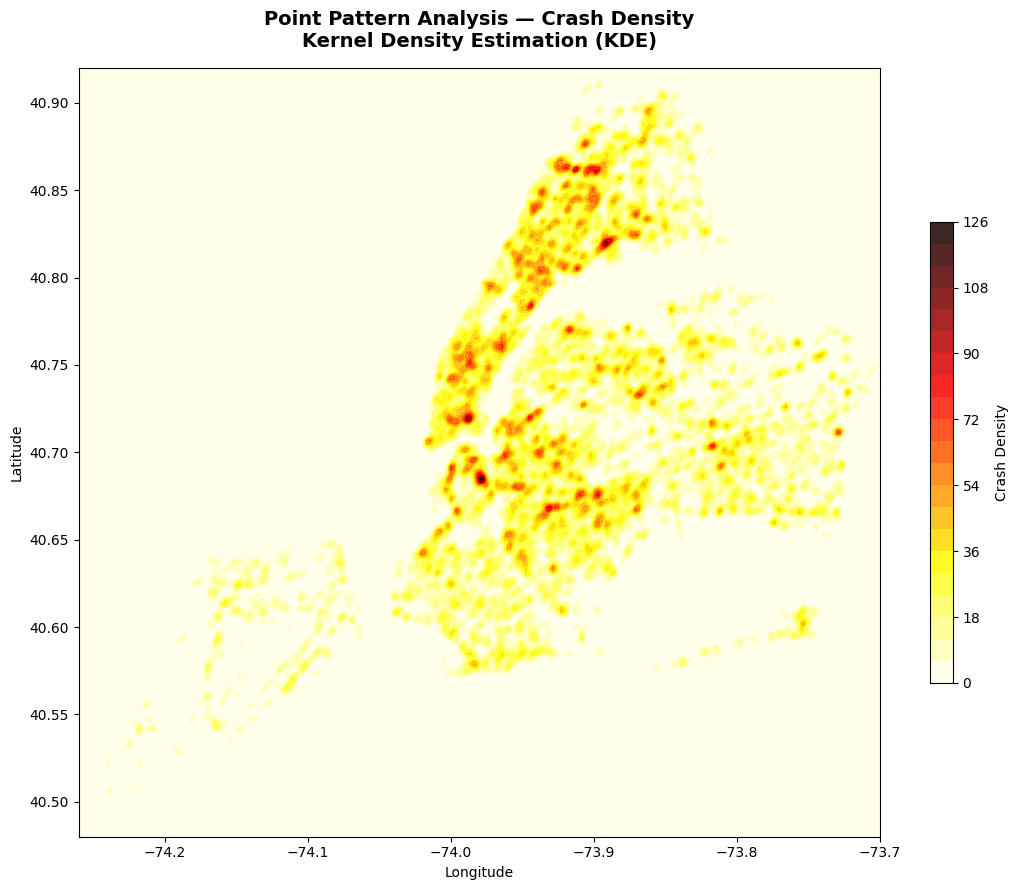

Saved point_pattern_kde.png


In [15]:
# ## Point Pattern Analysis
# 
# Are crashes randomly distributed across NYC or do they cluster?
# We use Kernel Density Estimation (KDE) to create a crash density surface.
# High density areas = crash hotspots.

from scipy.stats import gaussian_kde

# sample crashes for KDE
crash_sample = crashes[crashes['latitude'].notna()].sample(n=10000, random_state=42)
x = crash_sample['longitude'].values
y = crash_sample['latitude'].values

# fit KDE
kde = gaussian_kde(np.vstack([x, y]), bw_method=0.02)

# create grid over NYC
x_grid = np.linspace(-74.26, -73.70, 300)
y_grid = np.linspace(40.48,   40.92, 300)
xx, yy = np.meshgrid(x_grid, y_grid)
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(11, 9))
contour = ax.contourf(xx, yy, zz, levels=20, cmap='hot_r', alpha=0.85)
plt.colorbar(contour, ax=ax, label='Crash Density', shrink=0.6)

ax.set_title("Point Pattern Analysis — Crash Density\nKernel Density Estimation (KDE)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("../outputs/figures/point_pattern_kde.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved point_pattern_kde.png")

SPATIAL REGRESSION RESULTS
OLS R² (no spatial component):  0.5674
Spatial Lag R² (with neighbors): 0.5691
Improvement:                     +0.0016

Spatial lag coefficient: 0.0692
Positive coefficient confirms: neighboring road risk
significantly predicts a segment's own risk level.


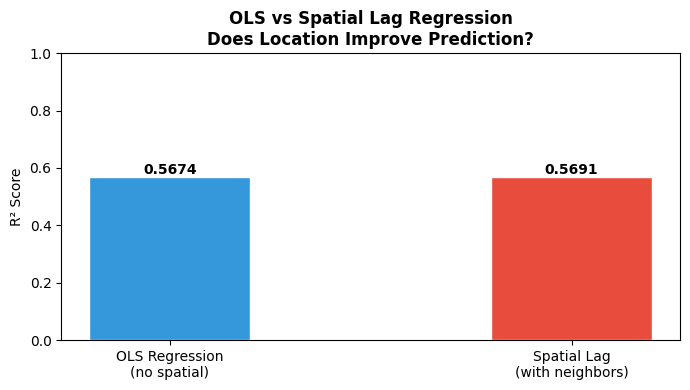

Saved spatial_regression.png


In [ ]:
# ## Spatial Regression
# 
# Standard regression ignores location — it treats each road segment independently.
# Spatial regression adds a "spatial lag" term — the average risk of neighboring segments.
# If spatial lag improves the model, it confirms crashes are spatially dependent.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import libpysal

# prepare features
sample['risk_num'] = sample['risk_class'].map({'Low':0,'Moderate':1,'High':2})

feature_cols = ['total_crashes','total_csi','total_injuries','total_fatalities']
available = [c for c in feature_cols if c in sample.columns]

X = sample[available].fillna(0).values
y = sample['risk_num'].values

# standard OLS regression (ignores space)
ols = LinearRegression().fit(X, y)
y_pred_ols = ols.predict(X)
r2_ols = r2_score(y, y_pred_ols)

# spatial lag — average risk of neighbors
w_matrix = libpysal.weights.Queen.from_dataframe(sample, silence_warnings=True)
w_matrix.transform = 'r'
spatial_lag = libpysal.weights.lag_spatial(w_matrix, y)

# spatial lag regression — adds neighbor risk as a feature
X_spatial = np.column_stack([X, spatial_lag])
slm = LinearRegression().fit(X_spatial, y)
y_pred_slm = slm.predict(X_spatial)
r2_slm = r2_score(y, y_pred_slm)

print("SPATIAL REGRESSION RESULTS")
print(f"OLS R² (no spatial component):  {r2_ols:.4f}")
print(f"Spatial Lag R² (with neighbors): {r2_slm:.4f}")
print(f"Improvement:                     +{r2_slm - r2_ols:.4f}")
print()
print("Spatial lag coefficient:", round(slm.coef_[-1], 4))
if slm.coef_[-1] > 0:
    print("Positive coefficient confirms: neighboring road risk")
    print("significantly predicts a segment's own risk level.")

# bar chart comparison
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['OLS Regression\n(no spatial)', 'Spatial Lag\n(with neighbors)'],
               [r2_ols, r2_slm],
               color=['#3498db','#e74c3c'], width=0.4, edgecolor='white')
ax.set_ylabel('R² Score')
ax.set_title('OLS vs Spatial Lag Regression\nDoes Location Improve Prediction?',
             fontweight='bold')
ax.set_ylim(0, 1)
for bar, val in zip(bars, [r2_ols, r2_slm]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("../outputs/figures/spatial_regression.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved spatial_regression.png")